In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
customer_churn = pd.read_csv('customer_churn_business_dataset.csv')

In [3]:
customer_churn.shape

(10000, 32)

In [4]:
print(customer_churn.columns.tolist())

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


In [42]:
customer_churn.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn,tenure_segment
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,Service,4.0,0,0.71,0.40,27,Satisfied,1,0,12-24 months
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1,6-12 months
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,Service,3.0,0,0.35,0.49,80,Neutral,1,0,24+ months
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,Technical,5.0,1,0.83,0.15,100,Neutral,0,0,12-24 months
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0,24+ months


In [7]:
customer_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

In [9]:
customer_churn.isnull().sum()

customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: i

In [10]:
customer_churn.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [11]:
churn_column = None
for col in customer_churn.columns:
    if 'churn' in col.lower():
        churn_column = col
        print(f"Found churn column: {col}")
        break

Found churn column: churn


In [12]:
customer_churn[churn_column].value_counts()

churn
0    8979
1    1021
Name: count, dtype: int64

In [13]:
churn_percent = customer_churn[churn_column].value_counts(normalize=True) * 100
print(f"\nNo Churn: {churn_percent[0]:.2f}%")
print(f"Churn: {churn_percent[1]:.2f}%")


No Churn: 89.79%
Churn: 10.21%


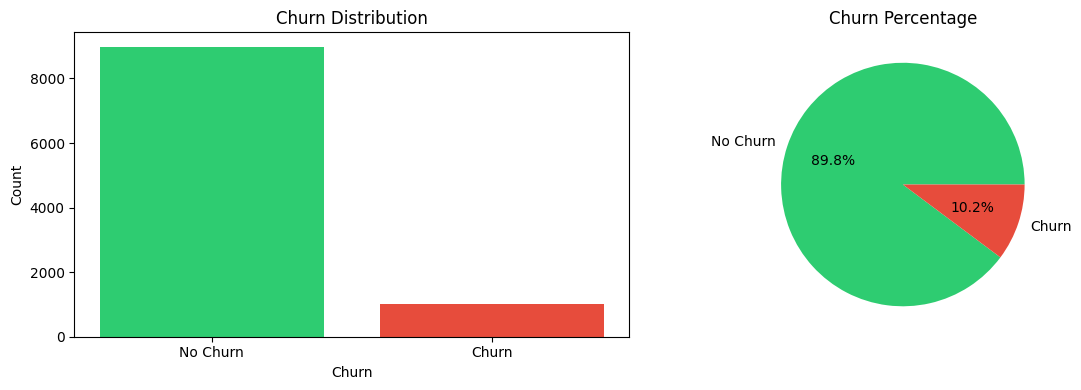

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = customer_churn[churn_column].value_counts()

axes[0].bar(['No Churn', 'Churn'],
            churn_counts.values,
            color=['#2ecc71', '#e74c3c'])

axes[0].set_title('Churn Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
                colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.show()

In [16]:
numeric_cols = customer_churn.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = customer_churn.select_dtypes(include=['object', 'category']).columns.tolist()

In [22]:
if churn_column in numeric_cols:
    numeric_cols.remove(churn_column)
if churn_column in categorical_cols:
    categorical_cols.remove(churn_column)

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features (19): ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count']

Categorical features (12): ['customer_id', 'gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']


In [23]:
if churn_column and churn_column in customer_churn.columns:
    correlations = customer_churn[numeric_cols + [churn_column]].corr()[churn_column].sort_values(ascending=False)
    print("Correlation with Churn:")
    print(correlations)

Correlation with Churn:
churn                   1.000000
payment_failures        0.112494
last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
total_revenue          -0.070120
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64


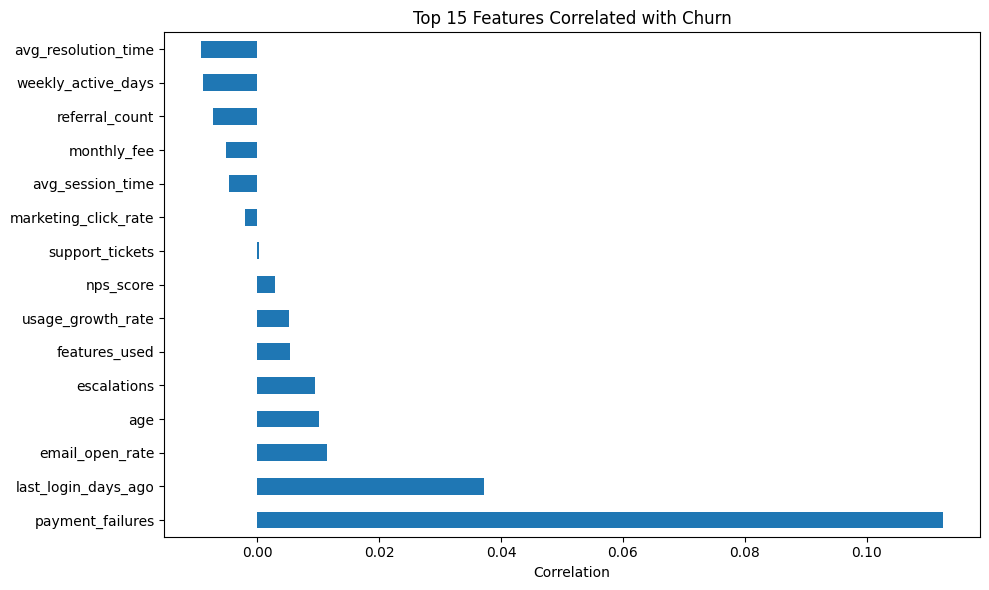

In [24]:
    fig, ax = plt.subplots(figsize=(10, 6))
    correlations.drop(churn_column).head(15).plot(kind='barh', ax=ax)
    ax.set_title('Top 15 Features Correlated with Churn')
    ax.set_xlabel('Correlation')
    plt.tight_layout()
    plt.show()

In [31]:
missing_summary = customer_churn.isnull().sum()
missing_summary

customer_id               0
gender                    0
age                       0
country                   0
city                      0
customer_segment          0
tenure_months             0
signup_channel            0
contract_type             0
monthly_logins            0
weekly_active_days        0
avg_session_time          0
features_used             0
usage_growth_rate         0
last_login_days_ago       0
monthly_fee               0
total_revenue             0
payment_method            0
payment_failures          0
discount_applied          0
price_increase_last_3m    0
support_tickets           0
avg_resolution_time       0
complaint_type            0
csat_score                0
escalations               0
email_open_rate           0
marketing_click_rate      0
nps_score                 0
survey_response           0
referral_count            0
churn                     0
dtype: int64

In [29]:
customer_churn['complaint_type'].fillna(customer_churn['complaint_type'].mode()[0], inplace=True)

In [37]:
# IQR method for outlier detection
def detect_outliers_iqr(data, columns, threshold=1.5):
    outliers = pd.DataFrame() 
    # outliers for store true or false
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        # 75% data இந்த மதிப்புக்கு கீழே இருக்கும்.
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        outlier_mask = (data[col] < lower_bound) | (data[col] > upper_bound)
        # in outlier_mask answers like true or false  
        outliers[col] = outlier_mask
    return outliers
# True → Outlier found
# False → Not an outlier

outliers = detect_outliers_iqr(customer_churn, numeric_cols)
outlier_count = (outliers.sum(axis=1) > 0).sum()
print(f"Rows with outliers: {outlier_count} ({outlier_count/len(customer_churn)*100:.2f}%)")
print(f"\nOutliers per feature:")
print(outliers.sum())

Rows with outliers: 1859 (18.59%)

Outliers per feature:
age                       0
tenure_months             0
monthly_logins           49
weekly_active_days        0
avg_session_time         27
features_used           121
usage_growth_rate        78
last_login_days_ago     471
monthly_fee             513
total_revenue           513
payment_failures        147
support_tickets          18
avg_resolution_time      38
csat_score              221
escalations              43
email_open_rate           0
marketing_click_rate      0
nps_score                36
referral_count            8
dtype: int64


In [41]:
# Create RFM-like features if applicable
# Adjust based on your dataset columns

# Example: Tenure-based segmentation
if 'tenure_months' in [col.lower() for col in customer_churn.columns]:
    tenure_col = [col for col in customer_churn.columns if col.lower() == 'tenure_months'][0]
    customer_churn['tenure_segment'] = pd.cut(customer_churn[tenure_col], bins=[0, 6, 12, 24, np.inf], 
                                   labels=['0-6 months', '6-12 months', '12-24 months', '24+ months'])
    print(f"Created tenure_segment feature")

# Add more feature engineering as needed for your dataset
print("\nFeature engineering complete!")

Created tenure_segment feature

Feature engineering complete!


In [43]:
# One-hot encode categorical features (except high-cardinality)
df_processed = customer_churn.copy()

for col in categorical_cols:
    unique_vals = df_processed[col].nunique()
    if unique_vals < 10:  # Only encode if not too many categories
        df_processed = pd.get_dummies(df_processed, columns=[col], drop_first=True)
        print(f"Encoded {col} ({unique_vals} categories)")
    else:
        print(f"Skipped {col} (too many categories: {unique_vals})")

print(f"\nProcessed dataset shape: {df_processed.shape}")

Skipped customer_id (too many categories: 10000)
Encoded gender (2 categories)
Encoded country (7 categories)
Encoded city (7 categories)
Encoded customer_segment (3 categories)
Encoded signup_channel (3 categories)
Encoded contract_type (3 categories)
Encoded payment_method (3 categories)
Encoded discount_applied (2 categories)
Encoded price_increase_last_3m (2 categories)
Encoded complaint_type (3 categories)
Encoded survey_response (3 categories)

Processed dataset shape: (10000, 49)


In [52]:
# Save processed dataset
import os

os.makedirs('data', exist_ok=True)

df_processed.to_csv(
    'data/churn_processed.csv',
    index=False
)
# df_processed.to_csv('churn-prediction-enhanced/data/churn_processed.csv', index=False)
print(f"✓ Saved processed data to: ../data/churn_processed.csv")
print(f"Final dataset shape: {df_processed.shape}")

✓ Saved processed data to: ../data/churn_processed.csv
Final dataset shape: (10000, 49)


In [54]:
print("="*50)
print("EDA & PREPROCESSING SUMMARY")
print("="*50)
print(f"\n✓ Raw rows: {len(customer_churn):,}")
print(f"✓ Processed rows: {len(df_processed):,}")
print(f"✓ Original features: {len(customer_churn.columns)}")
print(f"✓ Final features: {len(df_processed.columns)}")
if churn_column:
    print(f"✓ Churn rate: {customer_churn[churn_column].mean()*100:.2f}%")
print("\n✓ Next: Run 02_model_training.ipynb")

EDA & PREPROCESSING SUMMARY

✓ Raw rows: 10,000
✓ Processed rows: 10,000
✓ Original features: 33
✓ Final features: 49
✓ Churn rate: 10.21%

✓ Next: Run 02_model_training.ipynb
